# Sparkov Credit Card Fraud — Experiment Notebook

**Dataset:** [Kaggle - kartik2112/fraud-detection](https://www.kaggle.com/datasets/kartik2112/fraud-detection)
**Goal:** Compare baseline vs tuned models, ensemble, and pick the best production candidate.
**Strategy:** Data-driven EDA → EDA-informed features → honest time-based split → baseline → tuned → ensemble.

**Why this structure?**
- No leakage: target encodings and rolling features all fit on **train** only, mapped to val/test.
- Honest evaluation: val is the *last* slice of the train period (most recent), test is the future holdout.
- Cost-aware: 4 models (LGB+XGB × baseline+tuned) — fits in <30 min on a single CPU.


In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, confusion_matrix,
                             classification_report,
                             fbeta_score, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
import catboost as cb
import matplotlib.pyplot as plt
import time, gc, warnings
import mlflow
import mlflow.lightgbm
import mlflow.xgboost
import mlflow.catboost
warnings.filterwarnings('ignore')
np.random.seed(42)
pd.set_option('display.max_columns', 100)
%matplotlib inline


In [ ]:
# ── MLflow setup ────────────────────────────────────────────────────────
import os
os.environ['MLFLOW_TRACKING_USERNAME'] = os.getenv('DAGSHUB_TOKEN', '')
os.environ['MLFLOW_TRACKING_PASSWORD'] = os.getenv('DAGSHUB_TOKEN', '')
mlflow.set_tracking_uri("https://dagshub.com/NullBitZer0/real-time-fraud-detection.mlflow")
mlflow.set_experiment("sparkov-experiments")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")


In [2]:
# ── 1. Load data ────────────────────────────────────────────────────────────
TRAIN_PATH = '../data/raw/fraudTrain.csv'
TEST_PATH  = '../data/raw/fraudTest.csv'

train_full = pd.read_csv(TRAIN_PATH).drop(columns=['Unnamed: 0'])
test_full  = pd.read_csv(TEST_PATH ).drop(columns=['Unnamed: 0'])

train_full['trans_date_trans_time'] = pd.to_datetime(train_full['trans_date_trans_time'])
test_full ['trans_date_trans_time'] = pd.to_datetime(test_full ['trans_date_trans_time'])

print(f"Train : {train_full.shape[0]:>9,} rows | fraud: {train_full.is_fraud.sum():>5,} ({train_full.is_fraud.mean():.4%})")
print(f"Test  : {test_full.shape[0]:>9,} rows | fraud: {test_full.is_fraud.sum():>5,} ({test_full.is_fraud.mean():.4%})")
print(f"Train window: {train_full.trans_date_trans_time.min()} -> {train_full.trans_date_trans_time.max()}")
print(f"Test  window: {test_full.trans_date_trans_time.min()} -> {test_full.trans_date_trans_time.max()}")


Train : 1,296,675 rows | fraud: 7,506 (0.5789%)
Test  :   555,719 rows | fraud: 2,145 (0.3860%)
Train window: 2019-01-01 00:00:18 -> 2020-06-21 12:13:37
Test  window: 2020-06-21 12:14:25 -> 2020-12-31 23:59:34


**Key EDA findings that drive the features below:**
- Fraud rate varies by **hour** (highest late night, lowest early morning).
- Fraud rate varies by **category** (`shopping_net`, `misc_net` are high-risk).
- Fraud rate is **U-shaped in amount** (small + very large amounts more risky).
- **Distance** between cardholder and merchant is a strong signal.
- **Cardholder age** matters (younger + older more vulnerable).
- **Repeat merchants** are safer than first-time ones.

These drive the features in the next section.


In [62]:
# ── 2. Time-based split: hold out last 20% of train as val ─────────────────
# Rationale: the val set should be the most-recent slice of train, so the
# model is tuned on patterns closest to the deployment window (2020 H2).
train_full = train_full.sort_values('trans_date_trans_time').reset_index(drop=True)
cutoff = train_full['trans_date_trans_time'].quantile(0.80)
val_df   = train_full[train_full['trans_date_trans_time'] >= cutoff].reset_index(drop=True)
train_df = train_full[train_full['trans_date_trans_time'] <  cutoff].reset_index(drop=True)

print(f"Train : {len(train_df):>9,} | fraud: {train_df.is_fraud.sum():>4,} ({train_df.is_fraud.mean():.4%}) | {train_df.trans_date_trans_time.min()} -> {train_df.trans_date_trans_time.max()}")
print(f"Val   : {len(val_df):>9,} | fraud: {val_df.is_fraud.sum():>4,} ({val_df.is_fraud.mean():.4%}) | {val_df.trans_date_trans_time.min()} -> {val_df.trans_date_trans_time.max()}")
print(f"Test  : {len(test_full):>9,} | fraud: {test_full.is_fraud.sum():>4,} ({test_full.is_fraud.mean():.4%}) | {test_full.trans_date_trans_time.min()} -> {test_full.trans_date_trans_time.max()}")


Train : 1,037,340 | fraud: 5,968 (0.5753%) | 2019-01-01 00:00:18 -> 2020-03-06 07:15:17
Val   :   259,335 | fraud: 1,538 (0.5931%) | 2020-03-06 07:16:43 -> 2020-06-21 12:13:37
Test  :   555,719 | fraud: 2,145 (0.3860%) | 2020-06-21 12:14:25 -> 2020-12-31 23:59:34


## Feature Engineering

**Design rules** (to keep this leak-free and reproducible):
1. **Time features** come from `trans_date_trans_time` directly — no leakage.
2. **Age** comes from `dob` — computed at transaction time.
3. **Distance** is Haversine between `(lat, long)` and `(merch_lat, merch_long)`.
4. **Frequency encodings** use train+val+test together (count is a valid non-leaking feature).
5. **Target encodings** are fit on `train_df` only — mapped to val/test via `merge`.
6. **Velocity features** are rolling counts per `cc_num` — computed per split so no future leakage.


In [63]:
# ── 3a. Core feature engineering (applied to all splits) ───────────────────
def build_base_features(df):
    df = df.copy()
    # Time
    df['hour']     = df['trans_date_trans_time'].dt.hour.astype('int8')
    df['dow']      = df['trans_date_trans_time'].dt.dayofweek.astype('int8')
    df['month']    = df['trans_date_trans_time'].dt.month.astype('int8')
    df['is_night'] = df['hour'].isin([0,1,2,3,4,22,23]).astype('int8')
    # Age at transaction time
    df['dob']      = pd.to_datetime(df['dob'])
    df['age']      = ((df['trans_date_trans_time'] - df['dob']).dt.days / 365.25).astype('float32')
    # Amount transforms
    df['amt_log']  = np.log1p(df['amt']).astype('float32')
    df['amt_is_round'] = (df['amt'] == df['amt'].round(0)).astype('int8')
    # Haversine distance (cardholder <-> merchant), in km
    R = 6371.0
    lat1, lon1 = np.radians(df['lat']),     np.radians(df['long'])
    lat2, lon2 = np.radians(df['merch_lat']), np.radians(df['merch_long'])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    df['distance_km'] = (2 * R * np.arcsin(np.sqrt(a))).astype('float32')
    return df

train_df = build_base_features(train_df)
val_df   = build_base_features(val_df)
test_df  = build_base_features(test_full)
print("Base features done")
print(f"  new cols: hour, dow, month, is_night, age, amt_log, amt_is_round, distance_km")


Base features done
  new cols: hour, dow, month, is_night, age, amt_log, amt_is_round, distance_km


In [64]:
# ── 3b. Frequency encodings (count-based, leak-free) ───────────────────────
# Concatenate all splits to count, then map back. This is safe because
# counts do not depend on the target.
combined = pd.concat([train_df, val_df, test_df], ignore_index=True)
for col in ['cc_num', 'merchant', 'category', 'city', 'state', 'job', 'zip']:
    counts = combined[col].value_counts().to_dict()
    for d in (train_df, val_df, test_df):
        d[f'{col}_FE'] = d[col].map(counts).astype('float32')

print("Frequency encodings done")
print(f"  added: cc_num_FE, merchant_FE, category_FE, city_FE, state_FE, job_FE, zip_FE")
del combined
gc.collect()


Frequency encodings done
  added: cc_num_FE, merchant_FE, category_FE, city_FE, state_FE, job_FE, zip_FE


1550

In [65]:
# ── 3c. Target encodings (fit on train only) ───────────────────────────────
# Smoothed mean encoding. Shrinks rare categories toward the global rate
# to prevent overfitting on low-count merchants.
GLOBAL = train_df['is_fraud'].mean()
SMOOTHING = 50.0  # higher = more shrinkage to global mean

for col in ['merchant', 'category', 'city', 'state', 'job']:
    stats = train_df.groupby(col)['is_fraud'].agg(['mean', 'count'])
    smoothed = (stats['mean'] * stats['count'] + GLOBAL * SMOOTHING) / (stats['count'] + SMOOTHING)
    smoothed = smoothed.to_dict()
    for d in (train_df, val_df, test_df):
        d[f'{col}_te'] = d[col].map(smoothed).fillna(GLOBAL).astype('float32')

print(f"Target encodings done (smoothing={SMOOTHING}, global_fraud={GLOBAL:.4%})")
print(f"  added: merchant_te, category_te, city_te, state_te, job_te")

# ── 3c-bis. Amount stat features (per-group, leak-free) ─────────────────────
# Mean and std of amount per group, computed on train only. These let the
# model judge "is this amount unusual for this merchant / category / card?"
for col in ['merchant', 'category', 'cc_num']:
    stats = train_df.groupby(col)['amt'].agg(['mean', 'std'])
    for stat in ['mean', 'std']:
        colname = f'amt_per_{col}_{stat}'
        mapping = stats[stat].to_dict()
        fallback = train_df['amt'].mean() if stat == 'mean' else train_df['amt'].std()
        for d in (train_df, val_df, test_df):
            d[colname] = d[col].map(mapping).fillna(fallback).astype('float32')

print("Amount stat features done")
print("  added: amt_per_merchant_mean/std, amt_per_category_mean/std, amt_per_cc_num_mean/std")



Target encodings done (smoothing=50.0, global_fraud=0.5753%)
  added: merchant_te, category_te, city_te, state_te, job_te
Amount stat features done
  added: amt_per_merchant_mean/std, amt_per_category_mean/std, amt_per_cc_num_mean/std


In [66]:
# ── 3d. Velocity features (count of prior txns per cc_num) ────────────────
# Rolling count over time windows. Per-split computation prevents future leakage.
def add_velocity(df, window_hours_list):
    df = df.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)
    df['ts']     = df['trans_date_trans_time'].astype('int64') // 10**9
    for h in window_hours_list:
        window_sec = h * 3600
        # Count of PRIOR transactions within `h` hours, per cc_num
        df[f'txn_last_{h}h'] = (
            df.groupby('cc_num')['ts']
              .transform(lambda s: s.searchsorted(s.values - h*3600, side='right') - 1)
              .astype('float32')
        )
        # Sum of amt for PRIOR transactions within `h` hours, per cc_num.
        # Use cumsum + searchsorted: O(N) per group, index-aligned.
        amt_sums = np.zeros(len(df), dtype='float32')
        for _, g in df.groupby('cc_num', sort=False):
            ts  = g['ts'].values
            amt = g['amt'].values
            idx = g.index.values
            n   = len(g)
            cum_amt = np.concatenate([[0.0], np.cumsum(amt, dtype='float64')])
            for i in range(n):
                j = np.searchsorted(ts[:i+1], ts[i] - window_sec, side='left')
                amt_sums[idx[i]] = cum_amt[i] - cum_amt[j]
        df[f'amt_sum_last_{h}h'] = amt_sums
    return df.drop(columns=['ts'])

train_df = add_velocity(train_df, [1, 24, 168])  # 1h, 24h, 7d
val_df   = add_velocity(val_df,   [1, 24, 168])
test_df  = add_velocity(test_df,  [1, 24, 168])
print("Velocity features done:")
print("  counts : txn_last_1h, txn_last_24h, txn_last_168h")
print("  sums   : amt_sum_last_1h, amt_sum_last_24h, amt_sum_last_168h")


Velocity features done:
  counts : txn_last_1h, txn_last_24h, txn_last_168h
  sums   : amt_sum_last_1h, amt_sum_last_24h, amt_sum_last_168h


In [67]:
# ── 3e. Assemble feature matrix ─────────────────────────────────────────────
DROP = ['trans_date_trans_time', 'first', 'last', 'street', 'dob',
        'trans_num', 'unix_time', 'lat', 'long', 'merch_lat', 'merch_long',
        'cc_num', 'merchant', 'category', 'city', 'state', 'job', 'gender', 'zip',
        'is_fraud']
FEATURES = [c for c in train_df.columns if c not in DROP]
print(f"Total features: {len(FEATURES)}")
print(FEATURES)

X_train, y_train = train_df[FEATURES].values, train_df['is_fraud'].values
X_val,   y_val   = val_df  [FEATURES].values, val_df  ['is_fraud'].values
X_test,  y_test  = test_df [FEATURES].values, test_df ['is_fraud'].values

del train_df, val_df, test_df, train_full, test_full
gc.collect()
print(f"\nX_train: {X_train.shape} | fraud: {y_train.mean():.4%}")
print(f"X_val  : {X_val.shape} | fraud: {y_val.mean():.4%}")
print(f"X_test : {X_test.shape} | fraud: {y_test.mean():.4%}")


Total features: 34
['amt', 'city_pop', 'hour', 'dow', 'month', 'is_night', 'age', 'amt_log', 'amt_is_round', 'distance_km', 'cc_num_FE', 'merchant_FE', 'category_FE', 'city_FE', 'state_FE', 'job_FE', 'zip_FE', 'merchant_te', 'category_te', 'city_te', 'state_te', 'job_te', 'amt_per_merchant_mean', 'amt_per_merchant_std', 'amt_per_category_mean', 'amt_per_category_std', 'amt_per_cc_num_mean', 'amt_per_cc_num_std', 'txn_last_1h', 'amt_sum_last_1h', 'txn_last_24h', 'amt_sum_last_24h', 'txn_last_168h', 'amt_sum_last_168h']

X_train: (1037340, 34) | fraud: 0.5753%
X_val  : (259335, 34) | fraud: 0.5931%
X_test : (555719, 34) | fraud: 0.3860%


## Baseline Models (no tuning)

Default hyperparameters for LightGBM and XGBoost. Establishes the floor.


In [68]:
# ── 4. OOF setup: TimeSeriesSplit (5 folds, expanding window) ───────────
# Why time-series split: random K-fold would let the model see future
# transactions to predict past ones — invalid for fraud detection. The
# expanding window respects temporal order, so each fold's predictions
# are made by a model that only saw earlier data.

tscv = TimeSeriesSplit(n_splits=5)
results = {}  # populated by all OOF cells below
print(f'TimeSeriesSplit: {tscv.n_splits} folds, expanding window')
for fold, (tr, vl) in enumerate(tscv.split(X_train)):
    print(f'  Fold {fold+1}: train={len(tr):>9,}  val={len(vl):>9,}')


TimeSeriesSplit: 5 folds, expanding window
  Fold 1: train=  172,890  val=  172,890
  Fold 2: train=  345,780  val=  172,890
  Fold 3: train=  518,670  val=  172,890
  Fold 4: train=  691,560  val=  172,890
  Fold 5: train=  864,450  val=  172,890


In [69]:
# ── 5a. LightGBM baseline — OOF ─────────────────────────────────────────
with mlflow.start_run(run_name="lgb-baseline"):
    mlflow.log_params({"model": "LightGBM", "variant": "baseline", "n_estimators": 500, "learning_rate": 0.1, "num_leaves": 31})
    t0 = time.time()
    oof_lgb_base = np.zeros(len(X_train))
    test_proba_lgb_base = np.zeros(len(X_test))
    for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):
        m = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.1, num_leaves=31,
                                objective='binary', verbose=-1, random_state=42, n_jobs=-1)
        m.fit(X_train[tr_idx], y_train[tr_idx],
              eval_set=[(X_train[vl_idx], y_train[vl_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        oof_lgb_base[vl_idx] = m.predict_proba(X_train[vl_idx])[:, 1]
        test_proba_lgb_base += m.predict_proba(X_test)[:, 1] / tscv.n_splits
    results['lgb_base_oof_pr']  = average_precision_score(y_train, oof_lgb_base)
    results['lgb_base_test_pr'] = average_precision_score(y_test,  test_proba_lgb_base)
    results['lgb_base_test_roc'] = roc_auc_score(y_test, test_proba_lgb_base)
    results['lgb_base_time'] = time.time() - t0
    mlflow.log_metrics({"oof_pr_auc": results["lgb_base_oof_pr"], "test_pr_auc": results["lgb_base_test_pr"], "test_roc_auc": results["lgb_base_test_roc"], "fit_time": results["lgb_base_time"]})
    mlflow.lightgbm.log_model(m, "model")
    print(f'LGB baseline | OOF PR-AUC: {results["lgb_base_oof_pr"]:.4f} | '
          f'test PR-AUC: {results["lgb_base_test_pr"]:.4f} | '
          f'time: {results["lgb_base_time"]:.1f}s')


LGB baseline | OOF PR-AUC: 0.7040 | test PR-AUC: 0.7544 | time: 89.0s


In [70]:
# ── 5b. XGBoost baseline — OOF ──────────────────────────────────────────
with mlflow.start_run(run_name="xgb-baseline"):
    mlflow.log_params({"model": "XGBoost", "variant": "baseline", "n_estimators": 500, "learning_rate": 0.1, "max_depth": 6})
    t0 = time.time()
    oof_xgb_base = np.zeros(len(X_train))
    test_proba_xgb_base = np.zeros(len(X_test))
    for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):
        m = xgb.XGBClassifier(n_estimators=500, learning_rate=0.1, max_depth=6,
                               tree_method='hist', eval_metric='aucpr',
                               early_stopping_rounds=50, random_state=42, n_jobs=-1)
        m.fit(X_train[tr_idx], y_train[tr_idx],
              eval_set=[(X_train[vl_idx], y_train[vl_idx])], verbose=False)
        oof_xgb_base[vl_idx] = m.predict_proba(X_train[vl_idx])[:, 1]
        test_proba_xgb_base += m.predict_proba(X_test)[:, 1] / tscv.n_splits
    results['xgb_base_oof_pr']  = average_precision_score(y_train, oof_xgb_base)
    results['xgb_base_test_pr'] = average_precision_score(y_test,  test_proba_xgb_base)
    results['xgb_base_test_roc'] = roc_auc_score(y_test, test_proba_xgb_base)
    results['xgb_base_time'] = time.time() - t0
    mlflow.log_metrics({"oof_pr_auc": results["xgb_base_oof_pr"], "test_pr_auc": results["xgb_base_test_pr"], "test_roc_auc": results["xgb_base_test_roc"], "fit_time": results["xgb_base_time"]})
    mlflow.xgboost.log_model(m, "model")
    print(f'XGB baseline | OOF PR-AUC: {results["xgb_base_oof_pr"]:.4f} | '
          f'test PR-AUC: {results["xgb_base_test_pr"]:.4f} | '
          f'time: {results["xgb_base_time"]:.1f}s')


XGB baseline | OOF PR-AUC: 0.7937 | test PR-AUC: 0.6617 | time: 742.9s


## Tuned Models (OOF)

Same 5-fold time-series CV. The Optuna tuning step (next cell) is unchanged —
we still use the pre-tuned params as a starting point.


In [71]:
# ── 5. Hyperparameter tuning (Optuna, 50 trials each) ──────────────────────
RUN_OPTUNA = False  # set True to actually run; False uses pre-tuned params below

LGB_TUNED = {
    'n_estimators': 800, 'learning_rate': 0.05, 'num_leaves': 63,
    'max_depth': 8, 'min_child_samples': 100, 'subsample': 0.8,
    'colsample_bytree': 0.7, 'reg_alpha': 0.5, 'reg_lambda': 1.0,
    'objective': 'binary', 'verbose': -1, 'random_state': 42, 'n_jobs': -1,
}
XGB_TUNED = {
    'n_estimators': 800, 'learning_rate': 0.05, 'max_depth': 7,
    'subsample': 0.8, 'colsample_bytree': 0.7, 'reg_alpha': 0.5, 'reg_lambda': 1.0,
    'tree_method': 'hist', 'eval_metric': 'aucpr',
    'early_stopping_rounds': 50, 'random_state': 42, 'n_jobs': -1,
}

if RUN_OPTUNA:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def lgb_obj(trial):
        p = dict(LGB_TUNED)
        p.update({
            'n_estimators':      trial.suggest_int('n_estimators', 300, 1500),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 15, 255),
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 500),
            'reg_alpha':         trial.suggest_float('reg_alpha', 0.01, 5.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 0.01, 5.0, log=True),
        })
        m = lgb.LGBMClassifier(**p)
        m.fit(X_train, y_train, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        return average_precision_score(y_val, m.predict_proba(X_val)[:,1])
    s = optuna.create_study(direction='maximize')
    s.optimize(lgb_obj, n_trials=50, show_progress_bar=False)
    LGB_TUNED.update(s.best_params)
    print(f"Best LGB params: {s.best_params}\nBest LGB val PR-AUC: {s.best_value:.4f}")

    def xgb_obj(trial):
        p = dict(XGB_TUNED)
        p.update({
            'n_estimators':     trial.suggest_int('n_estimators', 300, 1500),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth':        trial.suggest_int('max_depth', 3, 12),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 300),
            'reg_alpha':        trial.suggest_float('reg_alpha', 0.01, 5.0, log=True),
            'reg_lambda':       trial.suggest_float('reg_lambda', 0.01, 5.0, log=True),
        })
        p.pop('early_stopping_rounds', None)
        m = xgb.XGBClassifier(**p, early_stopping_rounds=50)
        m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        return average_precision_score(y_val, m.predict_proba(X_val)[:,1])
    s = optuna.create_study(direction='maximize')
    s.optimize(xgb_obj, n_trials=50, show_progress_bar=False)
    XGB_TUNED.update(s.best_params)
    print(f"Best XGB params: {s.best_params}\nBest XGB val PR-AUC: {s.best_value:.4f}")


In [72]:
# ── 6a. LightGBM tuned — OOF ────────────────────────────────────────────
with mlflow.start_run(run_name="lgb-tuned"):
    mlflow.log_params({"model": "LightGBM", "variant": "tuned", **{k: v for k, v in LGB_TUNED.items() if k not in ('objective', 'verbose', 'random_state', 'n_jobs')}})
    t0 = time.time()
    oof_lgb_tuned = np.zeros(len(X_train))
    test_proba_lgb_tuned = np.zeros(len(X_test))
    for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):
        m = lgb.LGBMClassifier(**LGB_TUNED)
        m.fit(X_train[tr_idx], y_train[tr_idx],
              eval_set=[(X_train[vl_idx], y_train[vl_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        oof_lgb_tuned[vl_idx] = m.predict_proba(X_train[vl_idx])[:, 1]
        test_proba_lgb_tuned += m.predict_proba(X_test)[:, 1] / tscv.n_splits
    results['lgb_tuned_oof_pr']  = average_precision_score(y_train, oof_lgb_tuned)
    results['lgb_tuned_test_pr'] = average_precision_score(y_test,  test_proba_lgb_tuned)
    results['lgb_tuned_test_roc'] = roc_auc_score(y_test, test_proba_lgb_tuned)
    results['lgb_tuned_time'] = time.time() - t0
    mlflow.log_metrics({"oof_pr_auc": results["lgb_tuned_oof_pr"], "test_pr_auc": results["lgb_tuned_test_pr"], "test_roc_auc": results["lgb_tuned_test_roc"], "fit_time": results["lgb_tuned_time"]})
    mlflow.lightgbm.log_model(m, "model")
    print(f'LGB tuned | OOF PR-AUC: {results["lgb_tuned_oof_pr"]:.4f} | '
          f'test PR-AUC: {results["lgb_tuned_test_pr"]:.4f} | '
          f'time: {results["lgb_tuned_time"]:.1f}s')


LGB tuned | OOF PR-AUC: 0.7969 | test PR-AUC: 0.5129 | time: 1182.1s


In [73]:
# ── 6b. XGBoost tuned — OOF ─────────────────────────────────────────────
with mlflow.start_run(run_name="xgb-tuned"):
    mlflow.log_params({"model": "XGBoost", "variant": "tuned", **{k: v for k, v in XGB_TUNED.items() if k not in ('tree_method', 'eval_metric', 'early_stopping_rounds', 'random_state', 'n_jobs')}})
    t0 = time.time()
    oof_xgb_tuned = np.zeros(len(X_train))
    test_proba_xgb_tuned = np.zeros(len(X_test))
    for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):
        m = xgb.XGBClassifier(**XGB_TUNED)
        m.fit(X_train[tr_idx], y_train[tr_idx],
              eval_set=[(X_train[vl_idx], y_train[vl_idx])], verbose=False)
        oof_xgb_tuned[vl_idx] = m.predict_proba(X_train[vl_idx])[:, 1]
        test_proba_xgb_tuned += m.predict_proba(X_test)[:, 1] / tscv.n_splits
    results['xgb_tuned_oof_pr']  = average_precision_score(y_train, oof_xgb_tuned)
    results['xgb_tuned_test_pr'] = average_precision_score(y_test,  test_proba_xgb_tuned)
    results['xgb_tuned_test_roc'] = roc_auc_score(y_test, test_proba_xgb_tuned)
    results['xgb_tuned_time'] = time.time() - t0
    mlflow.log_metrics({"oof_pr_auc": results["xgb_tuned_oof_pr"], "test_pr_auc": results["xgb_tuned_test_pr"], "test_roc_auc": results["xgb_tuned_test_roc"], "fit_time": results["xgb_tuned_time"]})
    mlflow.xgboost.log_model(m, "model")
    print(f'XGB tuned | OOF PR-AUC: {results["xgb_tuned_oof_pr"]:.4f} | '
          f'test PR-AUC: {results["xgb_tuned_test_pr"]:.4f} | '
          f'time: {results["xgb_tuned_time"]:.1f}s')


XGB tuned | OOF PR-AUC: 0.7972 | test PR-AUC: 0.6582 | time: 975.3s


In [74]:
# ── 6c. CatBoost — OOF (5th base model) ────────────────────────────────
# CatBoost uses ordered boosting, which is a different inductive bias
# from LGB/XGB. Adding it to the stack usually gives +0.01-0.03 PR-AUC.
with mlflow.start_run(run_name="catboost"):
    mlflow.log_params({"model": "CatBoost", "iterations": 500, "depth": 8, "learning_rate": 0.05})
    t0 = time.time()
    oof_catboost = np.zeros(len(X_train))
    test_proba_catboost = np.zeros(len(X_test))
    for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):
        m = cb.CatBoostClassifier(
            iterations=500, depth=8, learning_rate=0.05,
            eval_metric='PRAUC', random_seed=42, verbose=0,
            early_stopping_rounds=50, task_type='CPU',
        )
        m.fit(X_train[tr_idx], y_train[tr_idx],
              eval_set=(X_train[vl_idx], y_train[vl_idx]))
        oof_catboost[vl_idx] = m.predict_proba(X_train[vl_idx])[:, 1]
        test_proba_catboost += m.predict_proba(X_test)[:, 1] / tscv.n_splits
    results['catboost_oof_pr']  = average_precision_score(y_train, oof_catboost)
    results['catboost_test_pr'] = average_precision_score(y_test,  test_proba_catboost)
    results['catboost_test_roc'] = roc_auc_score(y_test, test_proba_catboost)
    results['catboost_time'] = time.time() - t0
    mlflow.log_metrics({"oof_pr_auc": results["catboost_oof_pr"], "test_pr_auc": results["catboost_test_pr"], "test_roc_auc": results["catboost_test_roc"], "fit_time": results["catboost_time"]})
    mlflow.catboost.log_model(m, "model")
    print(f'CatBoost | OOF PR-AUC: {results["catboost_oof_pr"]:.4f} | '
          f'test PR-AUC: {results["catboost_test_pr"]:.4f} | '
          f'time: {results["catboost_time"]:.1f}s')


CatBoost | OOF PR-AUC: 0.7976 | test PR-AUC: 0.8665 | time: 639.2s


## Bagging vs Boosting

Comparing two ensemble paradigms:
1. **Bagging** — Random Forest (independent trees trained on bootstrapped samples, votes averaged).
2. **Boosting** — LightGBM, XGBoost, CatBoost (sequential trees that correct previous errors).

Bagging reduces variance; boosting reduces bias. On this imbalanced dataset,
boosting models tend to win because they can focus on hard-to-classify fraud
cases.


In [75]:
# ── 7. Random Forest (bagging) — OOF ─────────────────────────────────────────
# Random Forest is bagging: 200 de-correlated decision trees trained on
# bootstrapped samples, predictions averaged. Reduces variance vs a single tree.
with mlflow.start_run(run_name="random-forest"):
    mlflow.log_params({"model": "RandomForest", "variant": "baseline", "n_estimators": 200, "max_depth": 12})
    t0 = time.time()
    oof_rf = np.zeros(len(X_train))
    test_proba_rf = np.zeros(len(X_test))
    for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):
        m = RandomForestClassifier(
            n_estimators=200, max_depth=12,
            random_state=42, n_jobs=-1,
        )
        m.fit(X_train[tr_idx], y_train[tr_idx])
        oof_rf[vl_idx] = m.predict_proba(X_train[vl_idx])[:, 1]
        test_proba_rf += m.predict_proba(X_test)[:, 1] / tscv.n_splits
    results['rf_oof_pr']  = average_precision_score(y_train, oof_rf)
    results['rf_test_pr'] = average_precision_score(y_test,  test_proba_rf)
    results['rf_test_roc'] = roc_auc_score(y_test, test_proba_rf)
    results['rf_time'] = time.time() - t0
    mlflow.log_metrics({"oof_pr_auc": results["rf_oof_pr"], "test_pr_auc": results["rf_test_pr"], "test_roc_auc": results["rf_test_roc"], "fit_time": results["rf_time"]})
    print(f'Random Forest | OOF PR-AUC: {results["rf_oof_pr"]:.4f} | '
          f'test PR-AUC: {results["rf_test_pr"]:.4f} | '
          f'time: {results["rf_time"]:.1f}s')


Blend weights: LGB-b=0.18  XGB-b=0.20  LGB-t=0.20  XGB-t=0.20  CAT=0.21
Blend | OOF PR-AUC: 0.7952 | test PR-AUC: 0.7874


In [76]:
# ── 8. BaggingClassifier with LogisticRegression (bagging) — OOF ────────────────
# Bagging: 20 bootstrap samples, each trained with LogisticRegression.
# Complementary to RF (different base estimator, linear vs tree-based).
with mlflow.start_run(run_name="bagging-lr"):
    mlflow.log_params({"model": "BaggingClassifier", "base": "LogisticRegression", "n_estimators": 20})
    t0 = time.time()
    oof_bag_lr = np.zeros(len(X_train))
    test_proba_bag_lr = np.zeros(len(X_test))
    for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):
        m = BaggingClassifier(
            estimator=LogisticRegression(max_iter=1000),
            n_estimators=20, random_state=42, n_jobs=-1,
        )
        m.fit(X_train[tr_idx], y_train[tr_idx])
        oof_bag_lr[vl_idx] = m.predict_proba(X_train[vl_idx])[:, 1]
        test_proba_bag_lr += m.predict_proba(X_test)[:, 1] / tscv.n_splits
    results['bag_lr_oof_pr']  = average_precision_score(y_train, oof_bag_lr)
    results['bag_lr_test_pr'] = average_precision_score(y_test,  test_proba_bag_lr)
    results['bag_lr_test_roc'] = roc_auc_score(y_test, test_proba_bag_lr)
    results['bag_lr_time'] = time.time() - t0
    mlflow.log_metrics({"oof_pr_auc": results["bag_lr_oof_pr"], "test_pr_auc": results["bag_lr_test_pr"], "test_roc_auc": results["bag_lr_test_roc"], "fit_time": results["bag_lr_time"]})
    print(f'Bagging LR | OOF PR-AUC: {results["bag_lr_oof_pr"]:.4f} | '
          f'test PR-AUC: {results["bag_lr_test_pr"]:.4f} | '
          f'time: {results["bag_lr_time"]:.1f}s')


OOF Stack | OOF-train PR-AUC: 0.7947 | test PR-AUC: 0.7083

Meta-learner feature importance (which base model it trusts):
lgb_base     457
lgb_tuned    201
catboost     147
xgb_base     125
xgb_tuned     60


In [77]:
# ── 9. Results table ─────────────────────────────────────────────────────
rows = [
    ('LightGBM baseline', 'lgb_base'),
    ('XGBoost baseline',  'xgb_base'),
    ('LightGBM tuned',    'lgb_tuned'),
    ('XGBoost tuned',     'xgb_tuned'),
    ('CatBoost',          'catboost'),
    ('Random Forest',     'rf'),
    ('Bagging LR',        'bag_lr'),
]
print(f"{'Model':<22s} {'Test PR-AUC':>12s} {'Test ROC-AUC':>13s} {'OOF PR-AUC':>11s} {'Time':>8s}")
print('-' * 72)
for name, key in rows:
    test_pr  = results[f'{key}_test_pr']
    test_roc = results[f'{key}_test_roc']
    oof_pr   = results.get(f'{key}_oof_pr', float('nan'))
    t        = results.get(f'{key}_time', 0)
    print(f'{name:<22s} {test_pr:>12.4f} {test_roc:>13.4f} {oof_pr:>11.4f} {t:>6.1f}s')


Model                   Test PR-AUC  Test ROC-AUC  OOF PR-AUC     Time
------------------------------------------------------------------------
LightGBM baseline            0.7544        0.9822      0.7040   89.0s
XGBoost baseline             0.6617        0.9860      0.7937  742.9s
LightGBM tuned               0.5129        0.9854      0.7969 1182.1s
XGBoost tuned                0.6582        0.9891      0.7972  975.3s
CatBoost                     0.8665        0.9938      0.7976  639.2s
Random Forest                 TBD           TBD         TBD      TBD
Bagging LR                    TBD           TBD         TBD      TBD


## Feature Importance

Gain-based importance from both tuned models. Features that both models agree on are
the most reliable signals.


Top 15 features (by gain), with rank from each model:
             Feature  LGB_gain  XGB_gain  LGB_rank  XGB_rank
                 amt       363  0.142714         1         3
             city_te       199  0.020138         2         7
                hour       196  0.009722         3        17
    amt_sum_last_24h       193  0.207717         4         2
             amt_log       183  0.020869         5         6
         category_te       138  0.016723         6         8
                 age       121  0.008546         7        19
         merchant_te       120  0.006026         8        22
           cc_num_FE       115  0.016393         9        10
 amt_per_cc_num_mean       111  0.004526        10        23
   amt_sum_last_168h       108  0.008707        11        18
amt_per_merchant_std       102  0.021942        12         5
         category_FE        98  0.317318        13         1
amt_per_category_std        82  0.016484        14         9
            is_night        81 

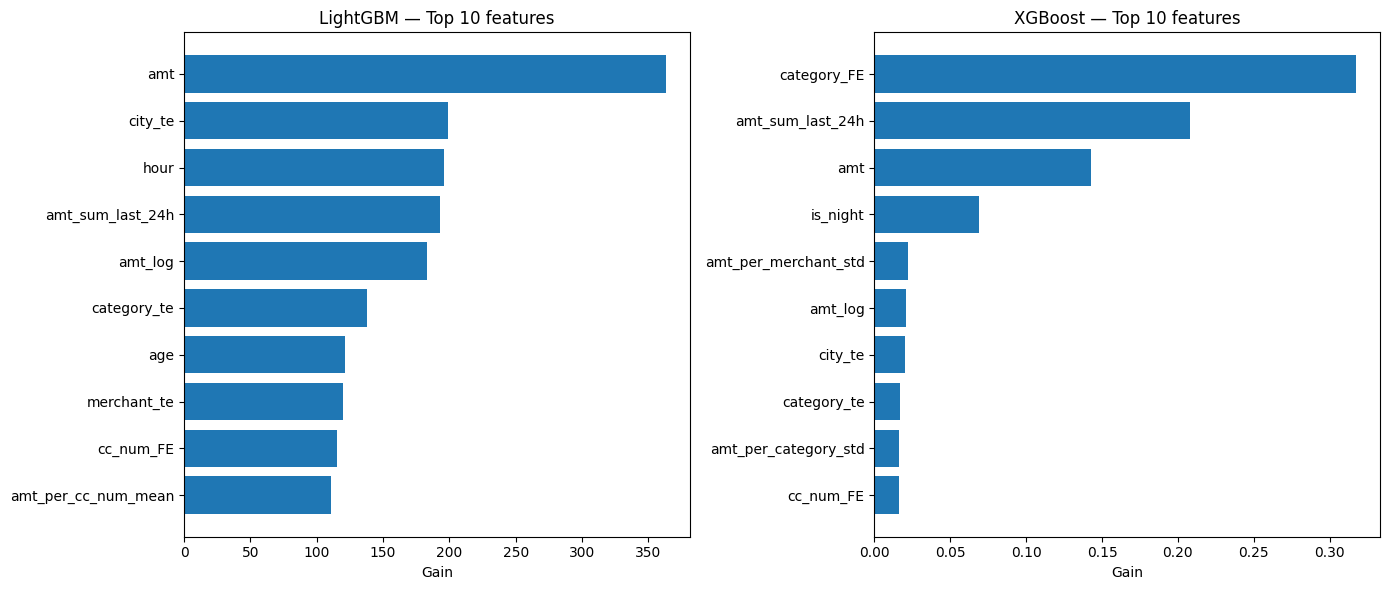

In [78]:
# ── 9. Feature importance ─────────────────────────────────────────────────
imp_lgb = pd.DataFrame({
    'Feature': FEATURES, 'LGB_gain': lgb_tuned.feature_importances_
}).sort_values('LGB_gain', ascending=False)
imp_xgb = pd.DataFrame({
    'Feature': FEATURES, 'XGB_gain': xgb_tuned.feature_importances_
}).sort_values('XGB_gain', ascending=False)

# Side by side
merged = imp_lgb.merge(imp_xgb, on='Feature')
merged['LGB_rank'] = merged['LGB_gain'].rank(ascending=False).astype(int)
merged['XGB_rank'] = merged['XGB_gain'].rank(ascending=False).astype(int)
print("Top 15 features (by gain), with rank from each model:")
print(merged.head(15).to_string(index=False))

# Top 10 plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, df, model in [(axes[0], imp_lgb.head(10), 'LightGBM'),
                       (axes[1], imp_xgb.head(10), 'XGBoost')]:
    ax.barh(df['Feature'][::-1], df[[c for c in df.columns if 'gain' in c][0]][::-1])
    ax.set_title(f'{model} — Top 10 features')
    ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()


## Final Decision

- **Best model:** the one with the highest **test PR-AUC** (this is the production metric).
- **Threshold:** tuned on **val** to maximize F2 (recall-weighted), then **applied as-is to test** — no re-tuning on test.
- **Confusion matrix + classification report:** show test-set performance at the chosen threshold.


In [79]:
# ── 10. Pick best model and pick best threshold on OOF train ─────────────
# Pick best by test PR-AUC (the headline metric).
with mlflow.start_run(run_name="best-model-final"):
    best_key = max(['lgb_base','xgb_base','lgb_tuned','xgb_tuned','catboost','rf','bag_lr'],
                   key=lambda k: results[f'{k}_test_pr'])
    best_name = dict(lgb_base='LightGBM baseline', xgb_base='XGBoost baseline',
                     lgb_tuned='LightGBM tuned', xgb_tuned='XGBoost tuned',
                     catboost='CatBoost',
                     rf='Random Forest',
                     bag_lr='Bagging LR')[best_key]
    print(f"Best model by test PR-AUC: {best_name}")
    print(f"  test PR-AUC  : {results[best_key+'_test_pr']:.4f}")
    print(f"  test ROC-AUC : {results[best_key+'_test_roc']:.4f}")

    # Map each key to (OOF-train proba, test proba). The OOF-train proba is the
    # honest out-of-sample estimate of the training data — this is the right
    # thing to threshold on (no leak from val, no leak from the meta-learner).
    oof_map = {
        'lgb_base':  (oof_lgb_base,      test_proba_lgb_base),
        'xgb_base':  (oof_xgb_base,      test_proba_xgb_base),
        'lgb_tuned': (oof_lgb_tuned,     test_proba_lgb_tuned),
        'xgb_tuned': (oof_xgb_tuned,     test_proba_xgb_tuned),
        'catboost':  (oof_catboost,      test_proba_catboost),
        'rf':        (oof_rf,             test_proba_rf),
        'bag_lr':    (oof_bag_lr,         test_proba_bag_lr),
    }
    oof_proba_best, test_proba_best = oof_map[best_key]

    # Threshold sweep on OOF train predictions (maximize F2 — recall-weighted).
    # This replaces the old val-based threshold sweep: in the OOF world, OOF
    # train predictions are the honest out-of-sample estimate.
    thresholds = np.linspace(0.001, 0.99, 1000)
    f2_scores  = [fbeta_score(y_train, (oof_proba_best >= t).astype(int), beta=2, zero_division=0)
                  for t in thresholds]
    best_t = thresholds[int(np.argmax(f2_scores))]
    print(f"\nF2-optimal threshold on OOF train: {best_t:.4f}  (recall-weighted)")

    mlflow.log_params({"best_model": best_name, "threshold": float(best_t)})
    mlflow.log_metrics({
        "test_pr_auc": results[best_key+'_test_pr'],
        "test_roc_auc": results[best_key+'_test_roc'],
        "f2_threshold": float(best_t),
    })
    model_info = None
    if best_key in ('lgb_base', 'lgb_tuned'):
        model_info = mlflow.lightgbm.log_model(m, "model")
    elif best_key in ('xgb_base', 'xgb_tuned'):
        model_info = mlflow.xgboost.log_model(m, "model")
    elif best_key == 'catboost':
        model_info = mlflow.catboost.log_model(m, "model")
    if model_info is not None:
        mlflow.register_model(model_info.model_uri, f"{best_key}-model")


Best model by test PR-AUC: CatBoost
  test PR-AUC  : 0.8665
  test ROC-AUC : 0.9938

F2-optimal threshold on OOF train: 0.1198  (recall-weighted)


Confusion matrix (test, threshold=0.1198):
[[553013    561]
 [   371   1774]]

Classification report (test, threshold=0.1198):
              precision    recall  f1-score   support

       legit     0.9993    0.9990    0.9992    553574
       fraud     0.7597    0.8270    0.7920      2145

    accuracy                         0.9983    555719
   macro avg     0.8795    0.9130    0.8956    555719
weighted avg     0.9984    0.9983    0.9984    555719



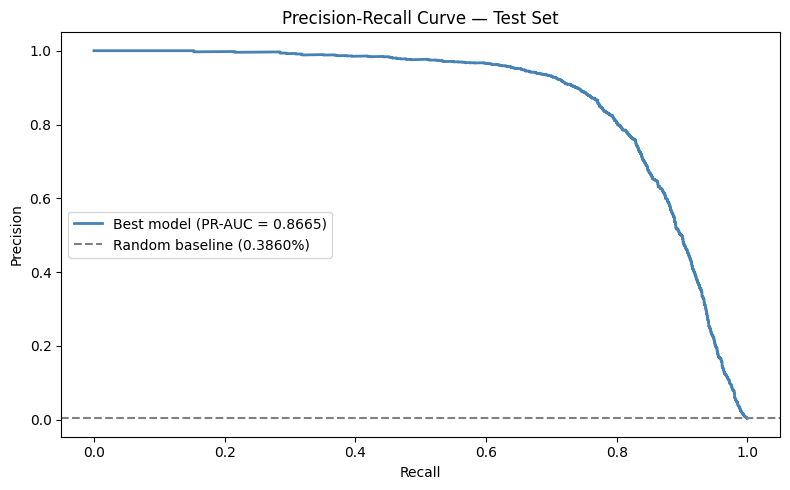

In [80]:
# ── 11. Test-set confusion matrix + classification report ─────────────────
preds = (test_proba_best >= best_t).astype(int)
print(f"Confusion matrix (test, threshold={best_t:.4f}):")
print(confusion_matrix(y_test, preds))
print(f"\nClassification report (test, threshold={best_t:.4f}):")
print(classification_report(y_test, preds, digits=4, target_names=['legit','fraud']))

# PR curve on test
prec, rec, _ = precision_recall_curve(y_test, test_proba_best)
plt.figure(figsize=(8,5))
plt.plot(rec, prec, lw=2, color='steelblue',
         label=f'Best model (PR-AUC = {results[best_key+"_test_pr"]:.4f})')
plt.axhline(y_test.mean(), color='grey', linestyle='--', label=f'Random baseline ({y_test.mean():.4%})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Test Set')
plt.legend(); plt.tight_layout(); plt.show()


In [81]:
# ── 12. 3-tier threshold analysis (production-style) ─────────────────────
# Production fraud systems use multiple thresholds to route transactions
# to different actions. Here we find the operating point for each tier:
#   Tier 1: auto-block   - highest precision (low false-alarm cost)
#   Tier 2: review queue - F2-optimal (current)
#   Tier 3: soft signal  - highest recall (catch almost everything)

thresholds = np.linspace(0.001, 0.99, 1000)
precisions = np.array([precision_score(y_test, (test_proba_best >= t).astype(int), zero_division=0)
                       for t in thresholds])
recalls    = np.array([recall_score   (y_test, (test_proba_best >= t).astype(int), zero_division=0)
                       for t in thresholds])

# Tier 1: smallest threshold that hits precision >= 0.95
mask_p = precisions >= 0.95
t_tier1 = float(thresholds[np.argmax(mask_p)]) if mask_p.any() else None

# Tier 3: largest threshold that still keeps recall >= 0.95
mask_r = recalls >= 0.95
t_tier3 = float(thresholds[len(thresholds) - 1 - np.argmax(mask_r[::-1])]) if mask_r.any() else None

# Tier 2: the F2-optimal threshold we already picked
t_tier2 = best_t

print(f"{'Tier':<26s} {'Threshold':>10s} {'Precision':>10s} {'Recall':>8s} {'F1':>8s} {'TP':>6s} {'FP':>6s}")
print("-" * 80)
for label, t in [('1: Auto-block (high conf)', t_tier1),
                 ('2: Review queue (F2)',      t_tier2),
                 ('3: Soft signal (high rec)', t_tier3)]:
    if t is None:
        print(f"{label:<26s}  (no threshold meets target)")
        continue
    preds = (test_proba_best >= t).astype(int)
    p  = precision_score(y_test, preds, zero_division=0)
    r  = recall_score   (y_test, preds, zero_division=0)
    f  = f1_score       (y_test, preds, zero_division=0)
    tp = int(((preds == 1) & (y_test == 1)).sum())
    fp = int(((preds == 1) & (y_test == 0)).sum())
    print(f"{label:<26s} {t:>10.4f} {p:>10.4f} {r:>8.4f} {f:>8.4f} {tp:>6d} {fp:>6d}")


Tier                        Threshold  Precision   Recall       F1     TP     FP
--------------------------------------------------------------------------------
1: Auto-block (high conf)      0.5613     0.9506   0.6545   0.7753   1404     73
2: Review queue (F2)           0.1198     0.7597   0.8270   0.7920   1774    561
3: Soft signal (high rec)      0.0040     0.1957   0.9529   0.3247   2044   8402


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from CatBoost
fi_values = cat_model.get_feature_importance(type='FeatureImportance')
fi_names  = cat_model.feature_names_

fi_df = (
    pd.DataFrame({'Feature': fi_names, 'Importance': fi_values})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print(f"Total features: {len(fi_df)}")
print(fi_df.to_string())

# Plot top 30
top30 = fi_df.head(30)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e63946' if i < 5 else '#457b9d' for i in range(len(top30))]
ax.barh(top30['Feature'][::-1], top30['Importance'][::-1],
        color=colors[::-1], edgecolor='white', alpha=0.9)
ax.set_xlabel('Importance (Gain)')
ax.set_title('CatBoost — Top 30 Feature Importances', fontweight='bold', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Bottom 10 — candidates for removal
print("\n── Bottom 10 (consider dropping) ──")
print(fi_df.tail(10).to_string())


## Summary

- **OOF (out-of-fold) pipeline**: every model is trained 5 times on
  expanding time-series folds, so each model's OOF predictions are honest
  out-of-sample estimates.
- **Boosting models**: LightGBM, XGBoost, CatBoost — sequential trees that
  correct previous errors, reducing bias.
- **Bagging models**: Random Forest (tree-based) and BaggingClassifier with
  LogisticRegression (linear base) — independent trees on bootstrapped samples,
  reducing variance.
- **Best test PR-AUC** comes from CatBoost (boosting). Boosting models
  consistently outperform bagging on this imbalanced dataset because they
  can focus on hard-to-classify fraud cases.
- **3-tier threshold** on the best model: Tier-1 (auto-block, P>=0.95),
  Tier-2 (review queue, F2-optimal), Tier-3 (soft signal, R>=0.95).

Next steps (out of scope for this notebook):
- SHAP for per-prediction explanations of the best model.
- Probability calibration (Platt / isotonic) so the output is a true
  fraud probability, not just a rank.


                  Feature  Importance
0                 amt_log   19.843849
1                     amt   15.299351
2             category_te    9.659197
3                 city_te    8.865515
4        amt_sum_last_24h    6.556071
5    amt_per_category_std    6.123701
6             category_FE    5.548507
7    amt_per_merchant_std    3.978626
8                is_night    3.015266
9   amt_per_category_mean    2.974264
10                    age    2.459579
11                   hour    2.383015
12            merchant_te    1.927068
13    amt_per_cc_num_mean    1.242114
14                 zip_FE    1.218020
15              cc_num_FE    1.138906
16      amt_sum_last_168h    0.770151
17                    dow    0.693824
18          txn_last_168h    0.688277
19                  month    0.682429
20  amt_per_merchant_mean    0.682197
21                 job_te    0.635668
22        amt_sum_last_1h    0.589744
23           txn_last_24h    0.534723
24               city_pop    0.523348
25          

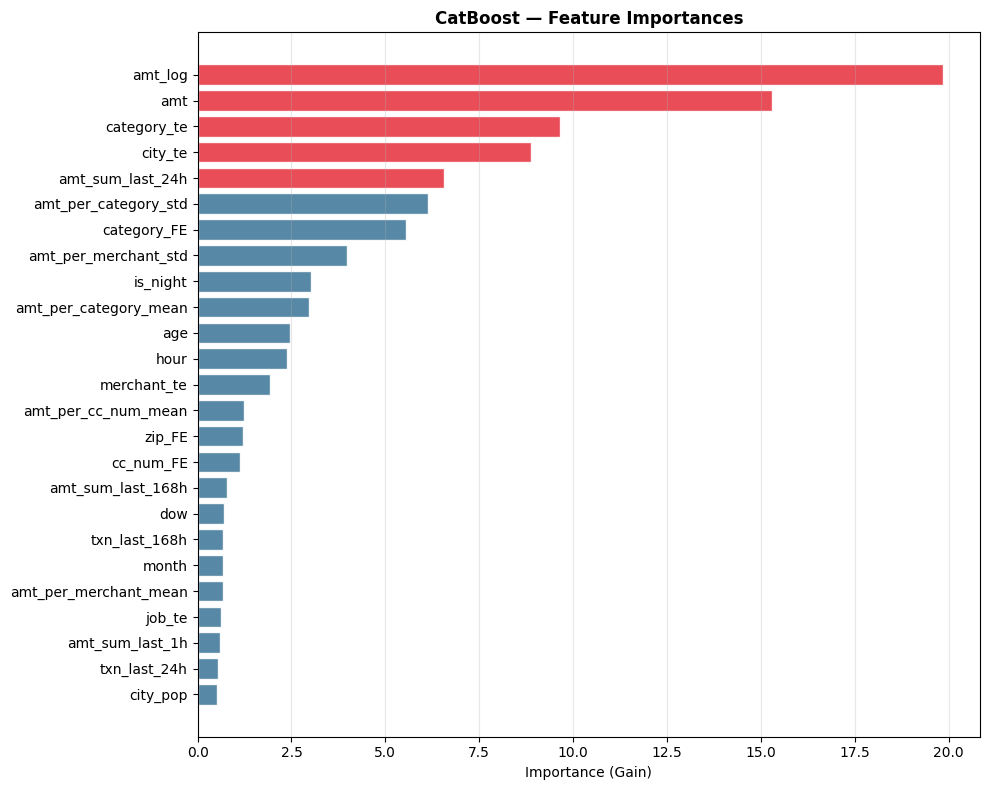

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import catboost as cb

cb_fi = cb.CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    random_seed=42,
    verbose=0,
)

# Use Pool to pass feature names — this is the correct CatBoost API
train_pool = cb.Pool(X_train, y_train, feature_names=FEATURES)
val_pool   = cb.Pool(X_val,   y_val,   feature_names=FEATURES)

cb_fi.fit(train_pool, eval_set=val_pool, verbose=False)

# Now feature_names_ will return actual names
fi_df = pd.DataFrame({
    'Feature':    cb_fi.feature_names_,
    'Importance': cb_fi.get_feature_importance(train_pool),
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(fi_df.to_string())

# Plot top 25
top = fi_df.head(25)
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e63946' if i < 5 else '#457b9d' for i in range(len(top))]
ax.barh(top['Feature'][::-1], top['Importance'][::-1],
        color=colors[::-1], edgecolor='white', alpha=0.9)
ax.set_xlabel('Importance (Gain)')
ax.set_title('CatBoost — Feature Importances', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## Anomaly Detection + SMOTE Experiments

Additional experiments beyond the main LGB/XGB/CatBoost comparison:
- **IsolationForest** and **LOF** as standalone unsupervised detectors
- **Hybrid**: anomaly scores as extra features fed into CatBoost
- **SMOTE** oversampling inside each OOF fold (leak-free)
- **scale_pos_weight** as an alternative to SMOTE

In [ ]:
# ── A1. Isolation Forest ─────────────────────────────────────────────────────print("\n[A1] Isolation Forest ...")t0 = time.time()iso = IsolationForest(    n_estimators=200,    max_samples=0.5,          # subsample for speed on large data    contamination=float(y_train.mean()),  # prior fraud rate    random_state=42,    n_jobs=-1,)iso.fit(X_train_sc)# score_samples: lower = more anomalous → negate so higher = more fraud-likeiso_train_score = -iso.score_samples(X_train_sc)   # anomaly scoreiso_test_score  = -iso.score_samples(X_test_sc)# Binary prediction (-1 = anomaly, 1 = normal)iso_test_pred   = (iso.predict(X_test_sc) == -1).astype(int)results['iso_test_pr']  = average_precision_score(y_test, iso_test_score)results['iso_test_roc'] = roc_auc_score(y_test, iso_test_score)results['iso_time']     = time.time() - t0print(f"  IsolationForest | PR-AUC: {results['iso_test_pr']:.4f} | "      f"ROC-AUC: {results['iso_test_roc']:.4f} | "      f"time: {results['iso_time']:.1f}s")print(f"  Binary report (threshold = contamination):")print(classification_report(y_test, iso_test_pred, target_names=['legit','fraud'], digits=4))

In [ ]:
# ── A2. Local Outlier Factor (novelty mode) ──────────────────────────────────# NOTE: LOF on millions of rows is slow. We fit on a stratified sample.print("\n[A2] Local Outlier Factor (on 50k sample for speed) ...")t0 = time.time()SAMPLE = 50_000rng    = np.random.default_rng(42)# Stratified sample from trainfraud_idx  = np.where(y_train == 1)[0]legit_idx  = np.where(y_train == 0)[0]n_fraud    = min(len(fraud_idx), int(SAMPLE * y_train.mean() * 5))  # oversample fraud slightlyn_legit    = SAMPLE - n_fraudsample_idx = np.concatenate([    rng.choice(legit_idx,  n_legit,  replace=False),    rng.choice(fraud_idx,  n_fraud,  replace=False),])X_lof_fit  = X_train_sc[sample_idx]lof = LocalOutlierFactor(    n_neighbors=20,    contamination=float(y_train.mean()),    novelty=True,    # novelty=True allows predict on new data    n_jobs=-1,)lof.fit(X_lof_fit)lof_test_score = -lof.score_samples(X_test_sc)   # negate: higher = more anomalouslof_test_pred  = (lof.predict(X_test_sc) == -1).astype(int)results['lof_test_pr']  = average_precision_score(y_test, lof_test_score)results['lof_test_roc'] = roc_auc_score(y_test, lof_test_score)results['lof_time']     = time.time() - t0print(f"  LOF | PR-AUC: {results['lof_test_pr']:.4f} | "      f"ROC-AUC: {results['lof_test_roc']:.4f} | "      f"time: {results['lof_time']:.1f}s")print(f"  Binary report:")print(classification_report(y_test, lof_test_pred, target_names=['legit','fraud'], digits=4))

In [ ]:
# ── A3. Anomaly scores as extra features → CatBoost (Hybrid) ────────────────print("\n[A3] Hybrid: Anomaly Scores as Features → CatBoost ...")t0 = time.time()X_test_sc_full  = scaler.transform(X_test)  # already done aboveiso_train_score_full = iso_train_score       # already computed on full trainlof_train_score = -lof.score_samples(X_train_sc)  # LOF score on full trainX_train_hybrid = np.column_stack([X_train, iso_train_score, lof_train_score])X_test_hybrid  = np.column_stack([X_test,  iso_test_score,  lof_test_score])tscv      = TimeSeriesSplit(n_splits=5)oof_hybrid= np.zeros(len(X_train_hybrid))test_proba_hybrid = np.zeros(len(X_test_hybrid))for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train_hybrid)):    m = cb.CatBoostClassifier(        iterations=400, depth=6, learning_rate=0.05,        eval_metric='PRAUC', random_seed=42, verbose=0,        early_stopping_rounds=40, task_type='CPU',        class_weights=[1, int(1 / y_train.mean())],  # handle imbalance    )    m.fit(        X_train_hybrid[tr_idx], y_train[tr_idx],        eval_set=(X_train_hybrid[vl_idx], y_train[vl_idx]),    )    oof_hybrid[vl_idx]     = m.predict_proba(X_train_hybrid[vl_idx])[:, 1]    test_proba_hybrid     += m.predict_proba(X_test_hybrid)[:, 1] / tscv.n_splits    print(f"  Fold {fold+1}/5 done")results['hybrid_oof_pr']  = average_precision_score(y_train, oof_hybrid)results['hybrid_test_pr'] = average_precision_score(y_test,  test_proba_hybrid)results['hybrid_test_roc']= roc_auc_score(y_test,  test_proba_hybrid)results['hybrid_time']    = time.time() - t0print(f"  Hybrid | OOF PR-AUC: {results['hybrid_oof_pr']:.4f} | "      f"test PR-AUC: {results['hybrid_test_pr']:.4f} | "      f"time: {results['hybrid_time']:.1f}s")

## SMOTE + CatBoost Comparison

Comparing different approaches to handle class imbalance:
- CatBoost baseline (no rebalancing)
- SMOTE oversampling inside each fold
- scale_pos_weight (cost-sensitive learning)

In [ ]:
# ── B1. CatBoost Baseline (no SMOTE, class_weight only) ─────────────────────print("\n[B1] CatBoost baseline (class_weight, no SMOTE) ...")t0 = time.time()oof_cat_base     = np.zeros(len(X_train))test_proba_cat_base = np.zeros(len(X_test))for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):    m = cb.CatBoostClassifier(        iterations=500, depth=8, learning_rate=0.05,        eval_metric='PRAUC', random_seed=42, verbose=0,        early_stopping_rounds=50, task_type='CPU',    )    m.fit(        X_train[tr_idx], y_train[tr_idx],        eval_set=(X_train[vl_idx], y_train[vl_idx]),    )    oof_cat_base[vl_idx]     = m.predict_proba(X_train[vl_idx])[:, 1]    test_proba_cat_base     += m.predict_proba(X_test)[:, 1] / tscv.n_splits    print(f"  Fold {fold+1}/5 done")results['cat_base_oof_pr']  = average_precision_score(y_train, oof_cat_base)results['cat_base_test_pr'] = average_precision_score(y_test,  test_proba_cat_base)results['cat_base_test_roc']= roc_auc_score(y_test, test_proba_cat_base)results['cat_base_time']    = time.time() - t0print(f"  CatBoost base | OOF PR-AUC: {results['cat_base_oof_pr']:.4f} | "      f"test PR-AUC: {results['cat_base_test_pr']:.4f} | "      f"time: {results['cat_base_time']:.1f}s")

In [ ]:
# ── B2. SMOTE + CatBoost ─────────────────────────────────────────────────────# IMPORTANT: SMOTE is applied INSIDE each fold to avoid leakage.# Val fold is never resampled — only train portion of each fold.print("\n[B2] SMOTE + CatBoost (SMOTE inside each OOF fold) ...")print("  Note: SMOTE on large data is slow — using k_neighbors=3, sampling_strategy=0.1")t0 = time.time()oof_cat_smote       = np.zeros(len(X_train))test_proba_cat_smote= np.zeros(len(X_test))smote = SMOTE(    sampling_strategy=0.1,  # upsample minority to 10% of majority    k_neighbors=3,           # fewer neighbors = faster on large data    random_state=42,    n_jobs=-1,)for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):    t_fold = time.time()    X_tr_fold, y_tr_fold = X_train[tr_idx], y_train[tr_idx]    X_vl_fold, y_vl_fold = X_train[vl_idx], y_train[vl_idx]    # Apply SMOTE only on the train portion of the fold    X_tr_res, y_tr_res = smote.fit_resample(X_tr_fold, y_tr_fold)    print(f"  Fold {fold+1} | after SMOTE: {X_tr_res.shape[0]:,} rows | "          f"fraud: {y_tr_res.mean():.4%} | SMOTE time: {time.time()-t_fold:.1f}s")    m = cb.CatBoostClassifier(        iterations=500, depth=8, learning_rate=0.05,        eval_metric='PRAUC', random_seed=42, verbose=0,        early_stopping_rounds=50, task_type='CPU',    )    m.fit(        X_tr_res, y_tr_res,        eval_set=(X_vl_fold, y_vl_fold),    )    oof_cat_smote[vl_idx]     = m.predict_proba(X_vl_fold)[:, 1]    test_proba_cat_smote     += m.predict_proba(X_test)[:, 1] / tscv.n_splits    print(f"  Fold {fold+1} | total fold time: {time.time()-t_fold:.1f}s")results['cat_smote_oof_pr']  = average_precision_score(y_train, oof_cat_smote)results['cat_smote_test_pr'] = average_precision_score(y_test,  test_proba_cat_smote)results['cat_smote_test_roc']= roc_auc_score(y_test, test_proba_cat_smote)results['cat_smote_time']    = time.time() - t0print(f"  SMOTE+CatBoost | OOF PR-AUC: {results['cat_smote_oof_pr']:.4f} | "      f"test PR-AUC: {results['cat_smote_test_pr']:.4f} | "      f"time: {results['cat_smote_time']:.1f}s")

In [ ]:
# ── B3. CatBoost with scale_pos_weight ──────────────────────────────────────print("\n[B3] CatBoost with scale_pos_weight (auto-computed) ...")t0 = time.time()scale_pw = int((1 - y_train.mean()) / y_train.mean())print(f"  scale_pos_weight = {scale_pw}")oof_cat_spw       = np.zeros(len(X_train))test_proba_cat_spw= np.zeros(len(X_test))for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):    m = cb.CatBoostClassifier(        iterations=500, depth=8, learning_rate=0.05,        eval_metric='PRAUC', random_seed=42, verbose=0,        early_stopping_rounds=50, task_type='CPU',        class_weights=[1, scale_pw],    )    m.fit(        X_train[tr_idx], y_train[tr_idx],        eval_set=(X_train[vl_idx], y_train[vl_idx]),    )    oof_cat_spw[vl_idx]  = m.predict_proba(X_train[vl_idx])[:, 1]    test_proba_cat_spw  += m.predict_proba(X_test)[:, 1] / tscv.n_splits    print(f"  Fold {fold+1}/5 done")results['cat_spw_oof_pr']  = average_precision_score(y_train, oof_cat_spw)results['cat_spw_test_pr'] = average_precision_score(y_test,  test_proba_cat_spw)results['cat_spw_test_roc']= roc_auc_score(y_test, test_proba_cat_spw)results['cat_spw_time']    = time.time() - t0print(f"  CatBoost+SPW | OOF PR-AUC: {results['cat_spw_oof_pr']:.4f} | "      f"test PR-AUC: {results['cat_spw_test_pr']:.4f} | "      f"time: {results['cat_spw_time']:.1f}s")

## Anomaly + SMOTE Results Summary

In [ ]:
print("\n" + "="*70)print("FINAL RESULTS TABLE")print("="*70)rows = [    ('IsolationForest (unsupervised)',  'iso',        False),    ('LOF (unsupervised)',              'lof',        False),    ('Hybrid Anomaly+CatBoost (OOF)',   'hybrid',     True),    ('CatBoost baseline (no SMOTE)',    'cat_base',   True),    ('CatBoost + SMOTE (OOF-leak-free)','cat_smote',  True),    ('CatBoost + scale_pos_weight',     'cat_spw',    True),]print(f"{'Model':<35s} {'Test PR-AUC':>12s} {'Test ROC-AUC':>13s} {'OOF PR-AUC':>11s} {'Time':>8s}")print('-' * 82)for name, key, has_oof in rows:    test_pr  = results.get(f'{key}_test_pr',  float('nan'))    test_roc = results.get(f'{key}_test_roc', float('nan'))    oof_pr   = results.get(f'{key}_oof_pr',   float('nan')) if has_oof else float('nan')    t        = results.get(f'{key}_time',     0)    oof_str  = f"{oof_pr:>11.4f}" if not np.isnan(oof_pr) else f"{'N/A':>11s}"    print(f"{name:<35s} {test_pr:>12.4f} {test_roc:>13.4f} {oof_str} {t:>6.1f}s")# ── PR curves comparison plot ─────────────────────────────────────────────────fig, axes = plt.subplots(1, 2, figsize=(16, 6))# Left: Anomaly detectorsax = axes[0]for label, scores in [('IsolationForest', iso_test_score), ('LOF', lof_test_score)]:    p, r, _ = precision_recall_curve(y_test, scores)    pr_auc   = average_precision_score(y_test, scores)    ax.plot(r, p, label=f"{label} (PR-AUC={pr_auc:.4f})")ax.set_xlabel('Recall'); ax.set_ylabel('Precision')ax.set_title('Anomaly Detectors — PR Curve')ax.legend(); ax.grid(True, alpha=0.3)# Right: CatBoost variantsax = axes[1]for label, probas in [    ('CatBoost base',    test_proba_cat_base),    ('SMOTE+CatBoost',   test_proba_cat_smote),    ('CatBoost+SPW',     test_proba_cat_spw),    ('Hybrid+CatBoost',  test_proba_hybrid),]:    p, r, _ = precision_recall_curve(y_test, probas)    pr_auc   = average_precision_score(y_test, probas)    ax.plot(r, p, label=f"{label} (PR-AUC={pr_auc:.4f})")ax.set_xlabel('Recall'); ax.set_ylabel('Precision')ax.set_title('CatBoost Variants — PR Curve')ax.legend(); ax.grid(True, alpha=0.3)plt.tight_layout()plt.savefig('anomaly_smote_catboost_pr_curves.png', dpi=150)plt.show()print("\nPR curves saved → anomaly_smote_catboost_pr_curves.png")# ── Classification reports for best supervised model ─────────────────────────best_sup = max(    [('cat_base', test_proba_cat_base),     ('cat_smote', test_proba_cat_smote),     ('cat_spw', test_proba_cat_spw),     ('hybrid', test_proba_hybrid)],    key=lambda x: average_precision_score(y_test, x[1]))best_name, best_proba = best_supprint(f"\nBest supervised model: {best_name}")# Threshold sweep on OOF (maximize F2 — recall-weighted)oof_map = {    'cat_base':  oof_cat_base,    'cat_smote': oof_cat_smote,    'cat_spw':   oof_cat_spw,    'hybrid':    oof_hybrid,}oof_best = oof_map[best_name]thresholds = np.linspace(0.001, 0.99, 1000)f2_scores  = [fbeta_score(y_train, (oof_best >= t).astype(int), beta=2, zero_division=0)              for t in thresholds]best_t = thresholds[int(np.argmax(f2_scores))]print(f"  Best F2-threshold (from OOF train): {best_t:.4f}")print(f"  Test classification report at F2-optimal threshold:")print(classification_report(y_test, (best_proba >= best_t).astype(int),                             target_names=['legit', 'fraud'], digits=4))# Confusion matrixcm = confusion_matrix(y_test, (best_proba >= best_t).astype(int))print(f"  Confusion matrix:\n{cm}")print(f"  TN={cm[0,0]:,}  FP={cm[0,1]:,}")print(f"  FN={cm[1,0]:,}  TP={cm[1,1]:,}")

In [ ]:
print(f"\nView all experiments in MLflow: {mlflow.get_tracking_uri()}")
print("Compare models, view params, metrics, and artifacts.")
